## Signal Transformation 

Information about the different signal transformation techniques goes here: 
resource: https://github.com/birth-outcomes/ctg_exploratory

Applying daydulo et. al signal transformation technique: 
resource: https://link.springer.com/article/10.1186/s12911-022-02068-1



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ssqueezepy import Wavelet, cwt
import os

In [3]:
# necessary imports
%pip install ssqueezepy
from dataclasses import dataclass
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy import signal
from sklearn.model_selection import train_test_split
from ssqueezepy import Wavelet, cwt
from ssqueezepy.utils import make_scales, cwt_scalebounds
from ssqueezepy.visuals import imshow

Note: you may need to restart the kernel to use updated packages.


In [4]:
''' 
Step 1: Define input folder path
Create a class for the paths to ensure single point of modification
'''
class paths:
    input_folder = '../cleaned_data/clean_csv'
    output_folder = './outputs/spectograms'
    labels_path = "../ExpertAnnotations/CTG_Majority_Vote_Labels_FINAL.csv"
    train = 'train'
    valid = 'validation'
    test = 'test'
    normal = 'class_0_normal'
    distress = 'class_1_distressed'

# Create output folder if it doesn't exist
os.makedirs(paths.output_folder, exist_ok=True)

### Seperate by Class Using Majority Voting Outcomes:
Normal Class and abnormal class 

Based on 9 expert clinicians opinions, the most agreed outcomes are presented

Normal class: 426

abnormal: 126



In [5]:
labels_df = pd.read_csv("../ExpertAnnotations/CTG_Majority_Vote_Labels_FINAL.csv")
labels_df["binary_label"] = labels_df["Majority_Vote_Label"].map({1: 0, 2: 1})
labels_df = labels_df.dropna(subset=["binary_label"])

In [6]:
labels_df["binary_label"] = labels_df["binary_label"].astype(int)
counts = labels_df["binary_label"].map({0: "normal", 1: "abnormal"}).value_counts()

In [7]:
print("Counts:\n", counts)
print("\nPercentages:\n", (counts / counts.sum() * 100).round(2))

Counts:
 normal      426
abnormal    126
Name: binary_label, dtype: int64

Percentages:
 normal      77.17
abnormal    22.83
Name: binary_label, dtype: float64


In [8]:
# Load and separate signals by class labels
csv_normal = {}
csv_distress = {}

for rec_id, label in zip(labels_df['rec_id'], labels_df['binary_label']):
	file_path = os.path.join(paths.input_folder, f'{rec_id}.csv')
	if os.path.exists(file_path):
		df = pd.read_csv(file_path)
		if label == 0:
			csv_normal[rec_id] = df
		else:
			csv_distress[rec_id] = df

### ****Signal pre-processing

Method from Daydulo et al. 2022

Signal pre-processing:

Long gaps (more than 15s) removed from the signal

Missing values at beginning and end of recording excluded to start from the stable point

Outside 50bpm or 200bpm are outliers

Outliers and small gaps were find and linearly interpolated using Matlab

Spikes are when beat is more than 25 from previous adjacent beat (not physiologic, unreliable) so removed using cubic spline interpolation.

Selected segment of the first 20 minutes (4800) and last 15 minutes (3600) to use and represent first and second stage of labour.

**CODE FROM: https://github.com/birth-outcomes/ctg_exploratory/blob/main/08_apply_daydulo_cwt.ipynb**

In [9]:
def daydulo_clean(fhr):
    '''
    Cleans fetal heart rate (FHR) signal according to Daydulo et al. 2022
    Inputs:
    fhr - series, the "FHR" column from one of the csv files
    '''

    # Replace 0 with NaN
    fhr.replace(0, np.nan, inplace=True)

    # Remove NaN if they occured for more than 15 seconds consecutively
    na = fhr.isnull()
    fhr = fhr[~(fhr.groupby(na.ne(na.shift()).cumsum().values).transform('size').ge(61) & na)].reset_index(drop=True)

    # Set outliers to NaN
    fhr[fhr < 50] = np.nan
    fhr[fhr > 200] = np.nan

    # Replace missing values using linear interpolation
    fhr = fhr.interpolate(method='linear')

    # Find how each value has changed from the prior value
    diff = fhr - fhr.shift()

    # Where difference is more than +- 25, set as NaN
    fhr[(diff > 25) | (diff < -25)] = np.nan

    # Replace missing values using cubic interpolation
    fhr = fhr.interpolate(method='cubic')

    return(fhr)

### Data Augmentation 
With the reference of Daydulo et al.
Perform augmentation on distressed records

Loop through files and clean them

In [10]:
def clean_signals(sig_dict):
    '''
    Cleans all signals in provided dictionary
    Inputs:
    - sig_dict - dictionary of dataframes which have FHR column for cleaning
    Outputs:
    - fhr_clean - dictionary of clean FHR signals
    '''
    fhr_clean = dict()
    for key, value in sig_dict.items():
        fhr_clean[key] = daydulo_clean(value.FHR)
    return fhr_clean

In [11]:
# Apply the cleaning function to both normal and distressed signals
fhr_normal_clean = clean_signals(csv_normal)
fhr_distress_clean = clean_signals(csv_distress)

print(f"Cleaned {len(fhr_normal_clean)} normal signals")
print(f"Cleaned {len(fhr_distress_clean)} distressed signals")
print(f"Total cleaned signals: {len(fhr_normal_clean) + len(fhr_distress_clean)}")

Cleaned 426 normal signals
Cleaned 126 distressed signals
Total cleaned signals: 552


In [12]:
def slicing_augmentation(
    fhr,
    fs=4,                 # CTG standard
    window_minutes=20,    # same window length as original
    shift_minutes=5,      # 5-minute backward shift
    n_shifts=2            # two slices as per paper
):
    window_len = window_minutes * 60 * fs
    shift_len = shift_minutes * 60 * fs

    augmented = []

    for i in range(n_shifts + 1):
        start = i * shift_len
        end = start + window_len

        if end <= len(fhr):
            augmented.append(fhr.iloc[start:end].reset_index(drop=True))

    return augmented


### *** CWT
MATLAB

Generalised Morse wavelet

Gamma (γ) parameter = 3

Time-bandwidth product (P2) = 60, 55 (figures use 5, 60, and 120) - ssqueezepy gmw accepts β. P2 = βγ, so used values of -

4 = β*3, so β=0.75

60 = β*3, so β=20

120 = β*3, so β=40

Voice for octave value of 12

The final dataset contains 1556 time frequency images, so they can't have repeated with two values of P2 - hence I will assume to use P2=60 as that is the one used in the figure and named first.

In [13]:
def daydulo_cwt(fhr, beta, axes):
    '''
    Perform CWT and plot scaleogram for replicating Daydulo at given values
    of beta and p2
    - fhr: series, FHR signal
    - beta: number, decay/compactness parameter, relates to p2, used for CWT
    - axes: axis object
    '''
    # Set parameters
    signal_length = len(fhr)
    wavelet = Wavelet(('gmw', {'gamma': 3, 'beta':beta}))
    voices_per_octave = 12

    # Find scales
    min_scale, max_scale = cwt_scalebounds(wavelet, signal_length)
    scales = make_scales(signal_length, scaletype='log', nv=voices_per_octave,
                        min_scale=min_scale, max_scale=max_scale)

    # Perform CWT
    Wx, _ = cwt(fhr, wavelet, scales=scales)

    # Visualise results in a scaleogram
    imshow(data=Wx, abs=1, show=False, yticks=1/scales, ax=axes,
           xlabel='Time (quarter of a second)', ylabel='Frequency')

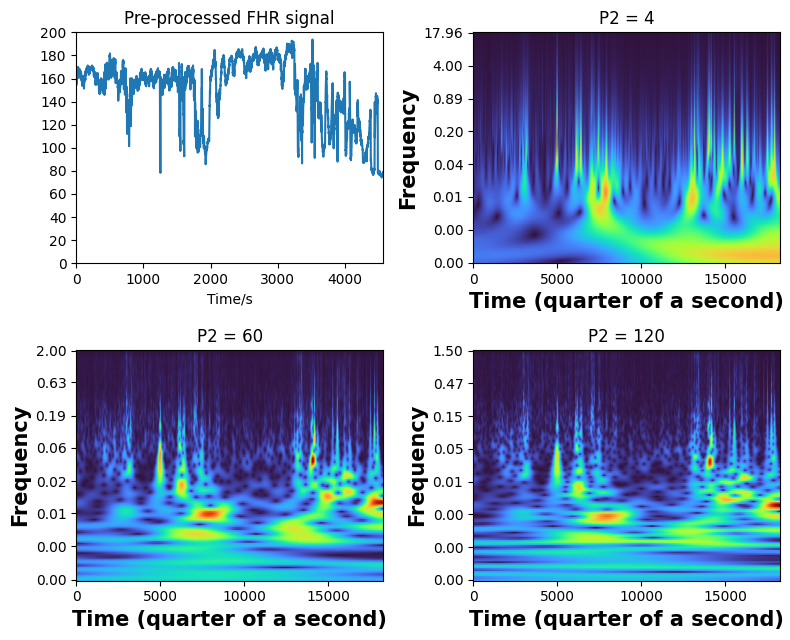

In [14]:
# Initialise plot
fig, ax = plt.subplots(2, 2, figsize=(8, 6.5))

# Plot clean FHR stage 1
ax[0,0].plot(fhr_distress_clean[1017].index/4,
             fhr_distress_clean[1017])
ax[0,0].margins(x=0)
ax[0,0].set_ylim(0, 200)
ax[0,0].set_xlabel('Time/s')
ax[0,0].set_title('Pre-processed FHR signal')
ax[0,0].set_yticks(np.arange(0, 201, 20))

# Plot CWT with different parameters
daydulo_cwt(fhr_distress_clean[1017], beta=0.75, axes=ax[0,1])
ax[0,1].set_title('P2 = 4')
daydulo_cwt(fhr_distress_clean[1017], beta=20, axes=ax[1,0])
ax[1,0].set_title('P2 = 60')
daydulo_cwt(fhr_distress_clean[1017], beta=40, axes=ax[1,1])
ax[1,1].set_title('P2 = 120')

plt.tight_layout()
plt.show()

### *** Save Images

When saving these images, we need to save by class and how dataset will be used. tf.keras.utils.image_dataset_from_directory() will look for the class folders within a main directory

In Daydulo et al. 2022,
 data split training : 
 validation (monitor performance and fine tune hyperparameters during training) : 
 test (evaluate model performance) was 80 : 10 : 10. 
 
 They state then that there were:

156 test records (88 normal and 68 distressed) = 10%

1400 training records (790 normal and 610 distressed) - from which, 10% of training data from each class was randomly selected for validation

For the record, 10% of 1400 is 140 records (9% of all records overall)

The remaining 90% of 1400 is 1260 records (81% of all records overall)

It therefore appears the split is actually 81% training, 9% validation and 10% test (81 : 9 : 10).

In [16]:
summary = pd.DataFrame({
    'class': ['normal']*3 + ['distress']*3,
    'set': ['train', 'validation', 'test']*2,
    'records': [ (790*0.9)/2, (790*0.1)/2, 88/2, (610*0.9)/2, (610*0.1)/2, 68/2]
})
summary

,class,set,records
0,normal,train,355.5
1,normal,validation,39.5
2,normal,test,44.0
3,distress,train,274.5
4,distress,validation,30.5
5,distress,test,34.0


In [17]:
print(f'''
Checking values...
Total records: {summary['records'].sum()}
Total test: {summary.loc[summary['set'] == 'test', 'records'].sum()}
Total train/validation: {summary.loc[summary['set'] != 'test', 'records'].sum()}
Total validation: {summary.loc[summary['set'] == 'validation', 'records'].sum()}
Total train: {summary.loc[summary['set'] == 'train', 'records'].sum()}
''')


Checking values...
Total records: 778.0
Total test: 78.0
Total train/validation: 700.0
Total validation: 70.0
Total train: 630.0



### Split records into sets, apply CWT, and save in appropriate file path

In [18]:
def apply_cwt(dict, file_path):
    '''
    Apply CWT to traces in the provided dictionary, saving files in the
    provided file path.
    Inputs:
    dict - dictionary of FHR signals, where record name will be image name
    file_path - path to folder to store the produced scaleograms
    '''
    for key, value in dict.items():

        # Perform CWT
        fig, ax = plt.subplots()
        daydulo_cwt(value, beta=20, axes=ax)

        # Remove axis and borders, and save as PNG file using record name
        plt.axis('off')
        plt.savefig(f'{file_path}/{key}.png',
                    bbox_inches='tight', pad_inches=0)

        # Close figure else struggles since creating lots in a loop
        plt.close(fig)

In [ ]:
def train_test_cwt(dict, path_class):
    '''
    Splits the dataset into training, validation and test data, and then
    performs CWT on each of those datasets and saves in the appropriate folders
    Inputs:
    dict - dictionary with FHR (either normal or distressed, and first or second stage)
    path_class - name of folder for appropriate class
    '''
    # Split the overall dataset into 90% train(/validate) and 10% test
    temp, test = train_test_split(
        list(dict.keys()),train_size=0.9, random_state=42)
    test_dict = {key: dict[key] for key in test}

    # Split the train/valdiation data into 90% train 10% validate
    train, valid = train_test_split(temp,train_size=0.9, random_state=42)
    
    train_dict = {}
    valid_dict = {key: dict[key] for key in valid}

    for key in train:
        signal_fhr = dict[key]

        # Always keep original
        train_dict[key] = signal_fhr

        # APPLY SLICING AUGMENTATION ONLY FOR DISTRESSED CLASS
        if path_class == paths.distress:
            slices = slicing_augmentation(signal_fhr)

            for i, sliced_fhr in enumerate(slices):
                aug_key = f"{key}_slice_{i}"
                train_dict[aug_key] = sliced_fhr

    # Print the length of those subsets
    print(f'Train {len(train)}, validation {len(valid)}, test {len(test)}')

    # Create folder paths if they don't yet exist
    train_path = os.path.join(paths.output_folder, paths.train, path_class)
    if not os.path.exists(train_path):
        os.makedirs(train_path)

    valid_path = os.path.join(paths.output_folder, paths.valid, path_class)
    if not os.path.exists(valid_path):
        os.makedirs(valid_path)

    test_path = os.path.join(paths.output_folder, paths.test, path_class)
    if not os.path.exists(test_path):
        os.makedirs(test_path)

    # Perform CWT and save the scaleograms
    apply_cwt(train_dict, train_path)
    apply_cwt(valid_dict, valid_path)
    apply_cwt(test_dict, test_path)

In [52]:
%%time
train_test_cwt(fhr_distress_clean, paths.distress)
train_test_cwt(fhr_normal_clean, paths.normal)

Train 101, validation 12, test 13
Train 344, validation 39, test 43
CPU times: total: 20min 2s
Wall time: 9min 14s


In [26]:
def count_images_in_folder(folder_path):
    return len([
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

base = paths.output_folder

folders_to_check = {
    "train_normal": os.path.join(base, paths.train, paths.normal),
    "train_distress": os.path.join(base, paths.train, paths.distress),
    "val_normal": os.path.join(base, paths.valid, paths.normal),
    "val_distress": os.path.join(base, paths.valid, paths.distress),
    "test_normal": os.path.join(base, paths.test, paths.normal),
    "test_distress": os.path.join(base, paths.test, paths.distress),
}

for name, path in folders_to_check.items():
    if os.path.exists(path):
        print(f"{name}: {count_images_in_folder(path)} images")
    else:
        print(f"{name}: folder not found")


train_normal: 344 images
train_distress: 404 images
val_normal: 39 images
val_distress: 12 images
test_normal: 43 images
test_distress: 13 images
